In [1]:
import numpy as np
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
from pysheds.rfsm import RFSM

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Definition:
Rapid Flood Spreading Method (RFSM)

TODO: Check RFSM Code, some modifications in order to make this code work were made, however, is not sure that the overall code is correct

# Load DEM

In [23]:
# Initialize grid and read the DEM
grid = Grid.from_raster('../data/roi.tif')
dem_full = grid.read_raster('../data/roi.tif')

# Subset the DEM to a 60x60 area where depressions exist
dem = dem_full[10:70, 0:60]

print(f"Full DEM shape: {dem_full.shape}")
print(f"Subset DEM shape: {dem.shape}")

Full DEM shape: (100, 70)
Subset DEM shape: (60, 60)


# Generate RFSM data structure

In [24]:
# Initialize the Rapid Flood Spreading Method topology
rfsm = RFSM(dem)

## Apply RFSM with 0.1 meters of uniformly distributed water

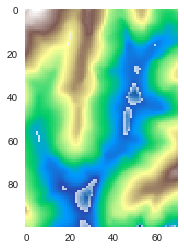

In [4]:
rfsm.reset_volumes()
input_vol = 0.1*900*np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)
plt.imshow(np.where(waterlevel, waterlevel - dem, np.nan), zorder=2, cmap='Blues', alpha=0.8)
plt.imshow(dem, zorder=1, cmap='terrain')

The cell area in the data is $30m \times 30m = 900m^2$.

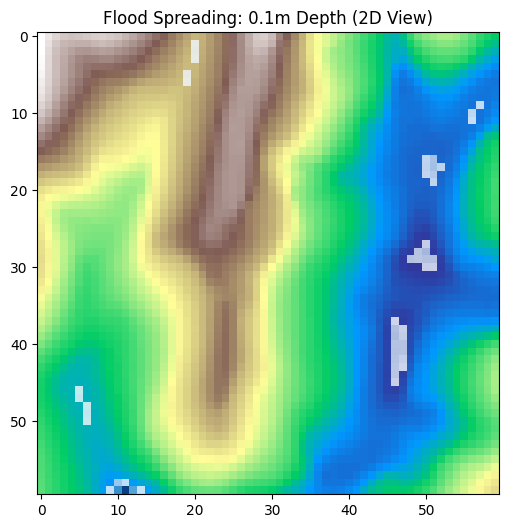

In [25]:
rfsm.reset_volumes()
# depth (m) * cell_area (m2) * ones_array
# Using 100 for 10m resolution data
input_vol = 0.1 * 100 * np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

fig, ax = plt.subplots(figsize=(8,6))
# depth = water surface - ground elevation
water_depth = np.where(waterlevel > dem, waterlevel - dem, np.nan)

ax.imshow(dem, zorder=1, cmap='terrain')
ax.imshow(water_depth, zorder=2, cmap='Blues', alpha=0.8)
ax.set_title("Flood Spreading: 0.1m Depth (2D View)")
plt.show()

## Apply RFSM with 0.25 meters of uniformly distributed water

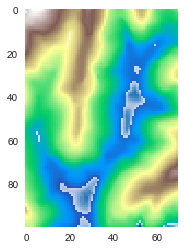

In [5]:
rfsm.reset_volumes()
input_vol = 0.25*900*np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)
plt.imshow(np.where(waterlevel, waterlevel - dem, np.nan), zorder=2, cmap='Blues', alpha=0.8)
plt.imshow(dem, zorder=1, cmap='terrain')

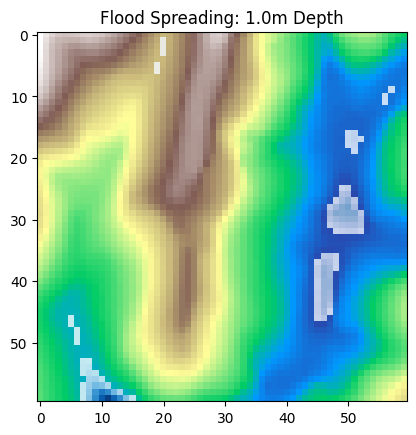

In [20]:
# For 1.0m
rfsm.reset_volumes()
input_vol = 1.0 * 100 * np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

water_depth = np.where(waterlevel > dem, waterlevel - dem, np.nan)
plt.imshow(dem, zorder=1, cmap='terrain')
plt.imshow(water_depth, zorder=2, cmap='Blues', alpha=0.8)
plt.title("Flood Spreading: 1.0m Depth")
plt.show()

## Apply RFSM with 1 meter of uniformly distributed water

In [6]:
rfsm.reset_volumes()
input_vol = 1*900*np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

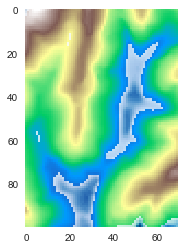

In [7]:
plt.imshow(np.where(waterlevel, waterlevel - dem, np.nan), zorder=2, cmap='Blues', alpha=0.8)
plt.imshow(dem, zorder=1, cmap='terrain')

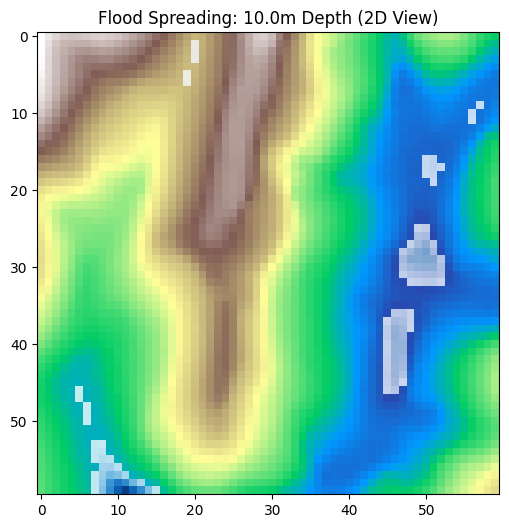

In [33]:
rfsm.reset_volumes()
input_vol = 1.0 * 100 * np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

fig, ax = plt.subplots(figsize=(8,6))
water_depth = np.where(waterlevel > dem, waterlevel - dem, np.nan)

ax.imshow(dem, zorder=1, cmap='terrain')
ax.imshow(water_depth, zorder=2, cmap='Blues', alpha=0.8)
ax.set_title("Flood Spreading: 10.0m Depth (2D View)")
plt.show()

In [35]:
# Sum up all the water currently held in the "buckets"
total_stored_vol = sum(node.current_vol for level in rfsm.nodes for node in level.values())
print(f"Total Input Volume: {input_vol.sum():.2f} m3")
print(f"Total Stored Volume: {total_stored_vol:.2f} m3")

if total_stored_vol < input_vol.sum():
    print("Warning: Water is spilling off the edges of your DEM slice!")

Total Input Volume: 360000.00 m3
Total Stored Volume: 271730.01 m3


In [36]:
print(f"Min Water Level: {np.nanmin(waterlevel)}")
print(f"Max Water Level: {np.nanmax(waterlevel)}")
print(f"Max Ground Elevation: {dem.max()}")

Min Water Level: 0.0
Max Water Level: 1139.5999755859375
Max Ground Elevation: 1219.0999755859375


## Visualize result in 3D

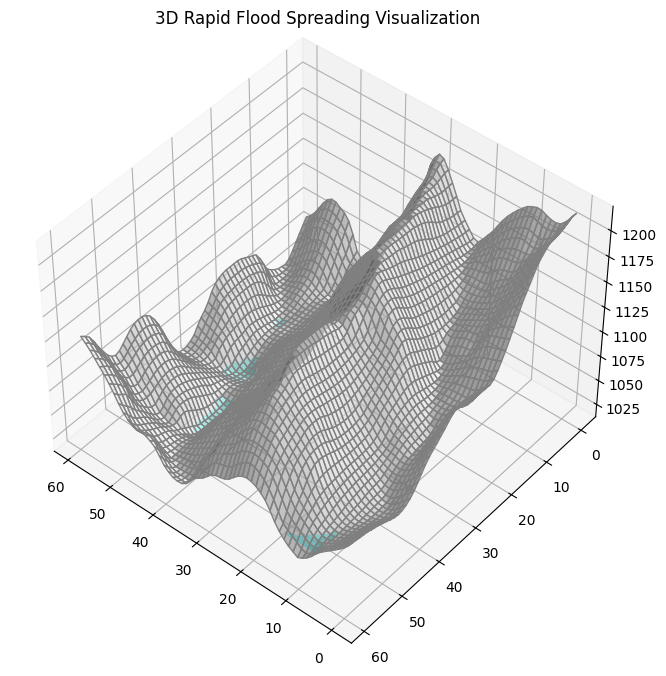

In [34]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Create coordinate meshes
X, Y = np.meshgrid(np.arange(dem.shape[1]), np.arange(dem.shape[0]))

# Critical Step: w_surface MUST be NaN where there is no water
# We add a tiny offset (+0.01) to the water height to help it render above the ground
w_surface = np.where(waterlevel > dem, waterlevel + 0.01, np.nan)

# Plot the terrain (Ground)
# rstride/cstride=1 ensures we see every pixel in this small 60x60 grid
ax.plot_surface(X, Y, dem, rstride=1, cstride=1, color='0.95', 
                antialiased=True, edgecolor='0.5', alpha=0.6)

# Plot the water surface (Blue/Cyan)
ax.plot_surface(X, Y, w_surface, rstride=1, cstride=1, color='cyan', 
                antialiased=True, alpha=0.6, shade=False)

ax.set_title("3D Rapid Flood Spreading Visualization")
ax.view_init(elev=45, azim=130) # Adjust angles to see the 'puddles' better
plt.show()

DEM Range: 1016.20 to 1219.10
Water Surface Range: 0.00 to 1139.60
Percentage of area flooded: 6.08%


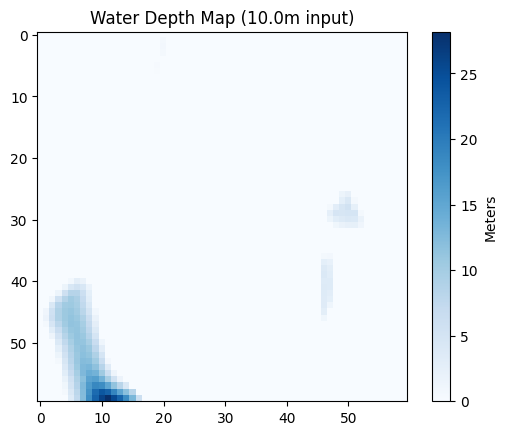

In [37]:
# 1. Reset
rfsm.reset_volumes()

# 2. Apply high volume
depth = 10.0
area = 100
input_vol = depth * area * np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

# 3. Stats
print(f"DEM Range: {dem.min():.2f} to {dem.max():.2f}")
print(f"Water Surface Range: {np.nanmin(waterlevel):.2f} to {np.nanmax(waterlevel):.2f}")

# 4. Visualization check
water_depth = np.where(waterlevel > dem, waterlevel - dem, 0)
flooded_cells = np.count_nonzero(water_depth > 0)
print(f"Percentage of area flooded: {(flooded_cells / dem.size)*100:.2f}%")

plt.imshow(water_depth, cmap='Blues')
plt.title(f"Water Depth Map ({depth}m input)")
plt.colorbar(label="Meters")
plt.show()

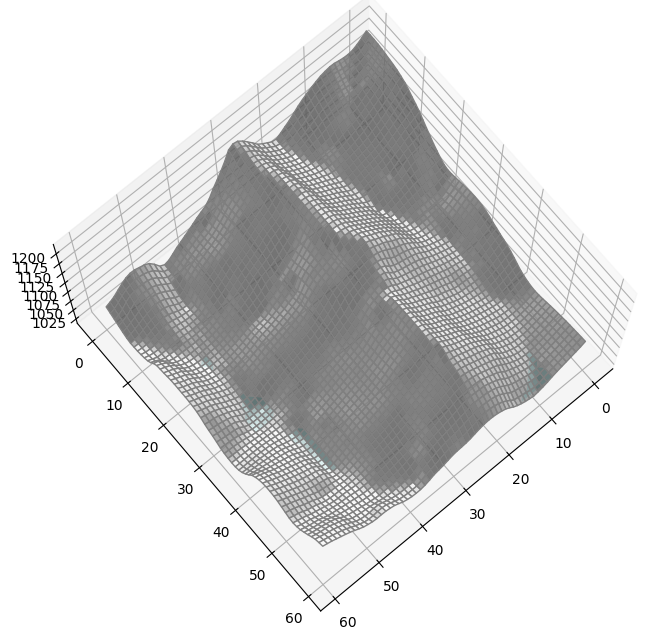

In [22]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))
# Modern way to create 3D axes
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Make data
X, Y = np.meshgrid(np.arange(dem.shape[1]), np.arange(dem.shape[0]))
# Absolute water surface
w_surface = np.where(waterlevel > dem, waterlevel, np.nan)

# Plot the surfaces
ax.plot_surface(X, Y, dem, rstride=1, cstride=1, color='0.99', 
                antialiased=True, edgecolor='0.5', alpha=0.8)
ax.plot_surface(X, Y, w_surface, rstride=1, cstride=1, color='c', 
                antialiased=True, alpha=0.5, shade=False)

ax.view_init(75, 50)
plt.savefig('./img/rfsm_3d.png', bbox_inches='tight')
plt.show()

# Load larger DEM

In [2]:
grid = Grid.from_raster('../data/dem.tif')
dem = grid.read_raster('../data/dem.tif')

# Generate RFSM data structure

Algorithm stabilized in 0 iterations.


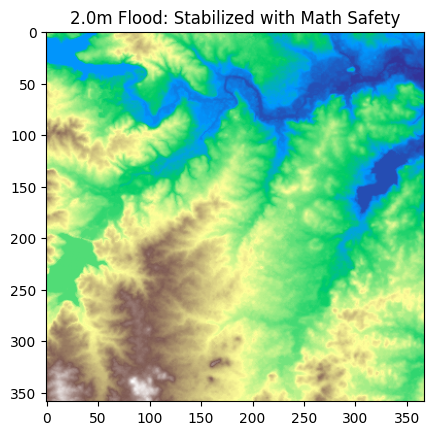

In [3]:
# Initialize
rfsm = RFSM(dem, max_spills=10000) 

# Compute
rfsm.reset_volumes()
input_vol = 2.0 * 100 * np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

# Plot
water_depth = np.where(waterlevel > dem, waterlevel - dem, np.nan)
plt.imshow(dem, cmap='terrain')
plt.imshow(water_depth, cmap='Blues', alpha=0.7)
plt.title("2.0m Flood: Stabilized with Math Safety")
plt.show()

## Apply RFSM with 4 meters of uniformly distributed water

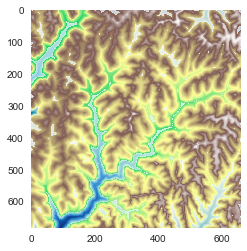

In [11]:
rfsm.reset_volumes()
input_vol = 4*900*np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)
plt.imshow(np.where(waterlevel, waterlevel - dem, np.nan), zorder=2, cmap='Blues', alpha=0.8)
plt.imshow(dem, zorder=1, cmap='terrain')

In [3]:
# 1. Start fresh with a reasonable max_spills
rfsm = RFSM(dem, max_spills=10000) 

# 2. Compute
rfsm.reset_volumes()
input_vol = 2.0 * 100 * np.ones(dem.shape)
waterlevel = rfsm.compute_waterlevel(input_vol)

# 3. Plot - This will now run even if there's a tiny warning!
water_depth = np.where(waterlevel > dem, waterlevel - dem, np.nan)
plt.imshow(dem, cmap='terrain')
plt.imshow(water_depth, cmap='Blues', alpha=0.7)
plt.show()

ValueError: f(a) and f(b) must have different signs

# Plot result in 3D

In [4]:
fig = plt.figure(figsize=(12,8))
ax = fig.gca(projection='3d')
plt.gca().patch.set_facecolor('white')

# Make data.
X = np.arange(dem.shape[1])
Y = np.arange(dem.shape[0])
X, Y = np.meshgrid(X, Y)
w = np.where(waterlevel, waterlevel, np.nan)
w.flat[0] = np.nan

# Plot the surface.
surf1 = ax.plot_surface(X, Y, dem, rstride=5, cstride=5, color='0.99', antialiased=True)
surf2 = ax.plot_surface(X, Y, w, color='c', antialiased=True, alpha=0.5, shade=False)

ax.view_init(80, 50)

TypeError: FigureBase.gca() got an unexpected keyword argument 'projection'

<Figure size 1200x800 with 0 Axes>

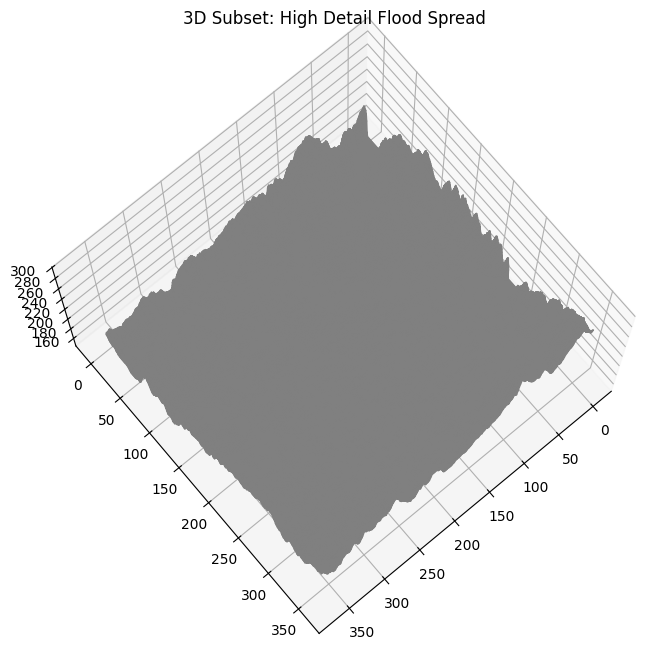

In [5]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
# Use the modern subplot approach
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Create the mesh based on the subset shape
X, Y = np.meshgrid(np.arange(dem.shape[1]), np.arange(dem.shape[0]))

# Create the water surface:
# 1. Mask where waterlevel is not higher than dem
# 2. Add a tiny offset (+0.02) to lift the water surface above the ground
w_surface = np.where(waterlevel > dem, waterlevel + 0.02, np.nan)

# Plot the Ground (High detail: stride=1)
ax.plot_surface(X, Y, dem, rstride=1, cstride=1, color='0.95', 
                antialiased=True, edgecolor='0.5', alpha=0.7)

# Plot the Water (High detail: stride=1)
ax.plot_surface(X, Y, w_surface, rstride=1, cstride=1, color='cyan', 
                antialiased=True, alpha=0.5, shade=False)

ax.view_init(elev=75, azim=50)
ax.set_title("3D Subset: High Detail Flood Spread")
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 8))
# Use add_subplot instead of gca to avoid the TypeError
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Make data
X, Y = np.meshgrid(np.arange(dem.shape[1]), np.arange(dem.shape[0]))

# FIX FOR VISIBILITY:
# 1. We mask out any water surface that isn't higher than the ground
# 2. We add a tiny offset (+0.05) to push the blue surface above the ground 
w_surface = np.where(waterlevel > dem, waterlevel + 0.05, np.nan)

# Plot the terrain surface
# Using stride=5 for the larger DEM to keep performance high
ax.plot_surface(X, Y, dem, rstride=5, cstride=5, color='0.99', 
                antialiased=True, edgecolor='0.5', alpha=0.6)

# Plot the water surface
ax.plot_surface(X, Y, w_surface, rstride=5, cstride=5, color='c', 
                antialiased=True, alpha=0.6, shade=False)

ax.view_init(80, 50)
ax.set_title("3D Large Scale Flood Spread")
plt.show()

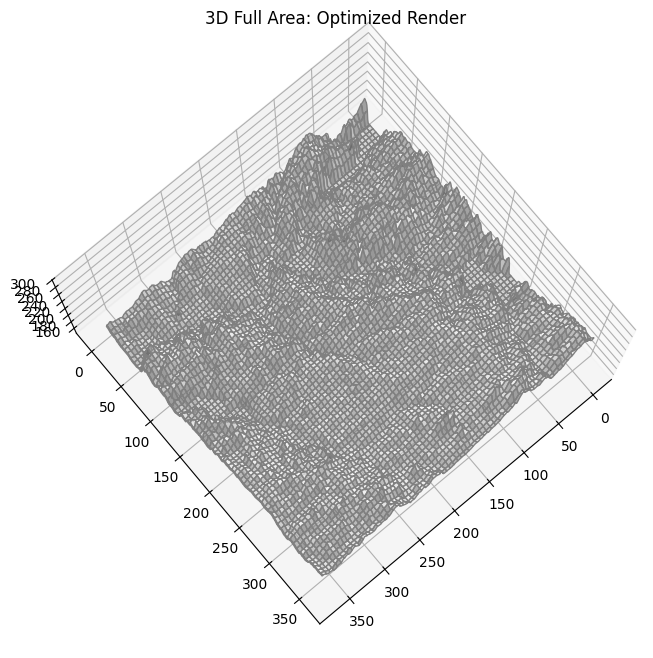

In [6]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Use coordinates for the full DEM
X, Y = np.meshgrid(np.arange(dem.shape[1]), np.arange(dem.shape[0]))

# Slightly larger offset (+0.05) often helps with visibility on larger scales
w_surface = np.where(waterlevel > dem, waterlevel + 0.05, np.nan)

# Plot the Ground (Optimized: stride=5)
ax.plot_surface(X, Y, dem, rstride=5, cstride=5, color='0.99', 
                antialiased=True, edgecolor='0.5', alpha=0.6)

# Plot the Water (Optimized: stride=5)
ax.plot_surface(X, Y, w_surface, rstride=5, cstride=5, color='royalblue', 
                antialiased=True, alpha=0.5, shade=False)

ax.view_init(elev=80, azim=50)
ax.set_title("3D Full Area: Optimized Render")
plt.show()